# Parametrische und Nichtparametrische Tests – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/parametrische-und-nichtparametrische-tests)

**Entscheidungsgrundlage:** Sind die Daten normalverteilt?

| | **Parametrisch** | **Nichtparametrisch** |
|---|---|---|
| **Voraussetzung** | Normalverteilung, metrische AV | Keine Verteilungsannahme |
| **Grundlage** | Mittelwerte, Varianzen | Ränge der Werte |
| **Teststärke** | Höher (wenn Voraussetzungen erfüllt) | Geringer |
| **Robustheit** | Geringer | Höher |
| **Wann verwenden?** | NV gegeben, n ≥ 30, metrisch | NV verletzt, ordinal, kleine n |

### Übersicht: Parametrisch vs. Nichtparametrisch (numiqo)

| Situation | Parametrisch | Nichtparametrisch |
|---|---|---|
| 1 Stichprobe | Einstichproben-t-Test | Wilcoxon (1 Stichprobe) |
| 2 abhängige Stichproben | Gepaarter t-Test | Wilcoxon-Test |
| 2 unabhängige Stichproben | Ungepaarter t-Test | Mann-Whitney-U-Test |
| 3+ unabhängige Stichproben | Einfaktorielle ANOVA | Kruskal-Wallis-Test |
| 3+ abhängige Stichproben | ANOVA mit Messwiederholung | Friedman-Test |
| Korrelation | Pearson-Korrelation | Spearman-Korrelation |

In [23]:
import matplotlib
matplotlib.use("Agg")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, norm as norm_dist

# matplotlib rendert di ePlots direkt im Notebook ohne plt.show()
%matplotlib inline

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Wann welchen Test verwenden?

**Entscheidungsbaum:**

1. **Skalenniveau?**
   - Nominal → Chi-Quadrat, Binomialtest
   - Ordinal → Nichtparametrisch
   - Metrisch → weiter zu Schritt 2

2. **Normalverteilung?** (Shapiro-Wilk oder Q-Q-Plot)
   - Ja (p > 0,05) → **Parametrisch**
   - Nein (p ≤ 0,05) → **Nichtparametrisch**

3. **Stichprobengröße n < 30?**
   - Ja → Normalverteilung nicht sicher annehmbar → Nichtparametrisch oder prüfen

> **numiqo:** Wenn die Voraussetzungen nicht erfüllt sind, Haken bei
> „Parametrischer Test" entfernen → automatisch nichtparametrisches Pendant.

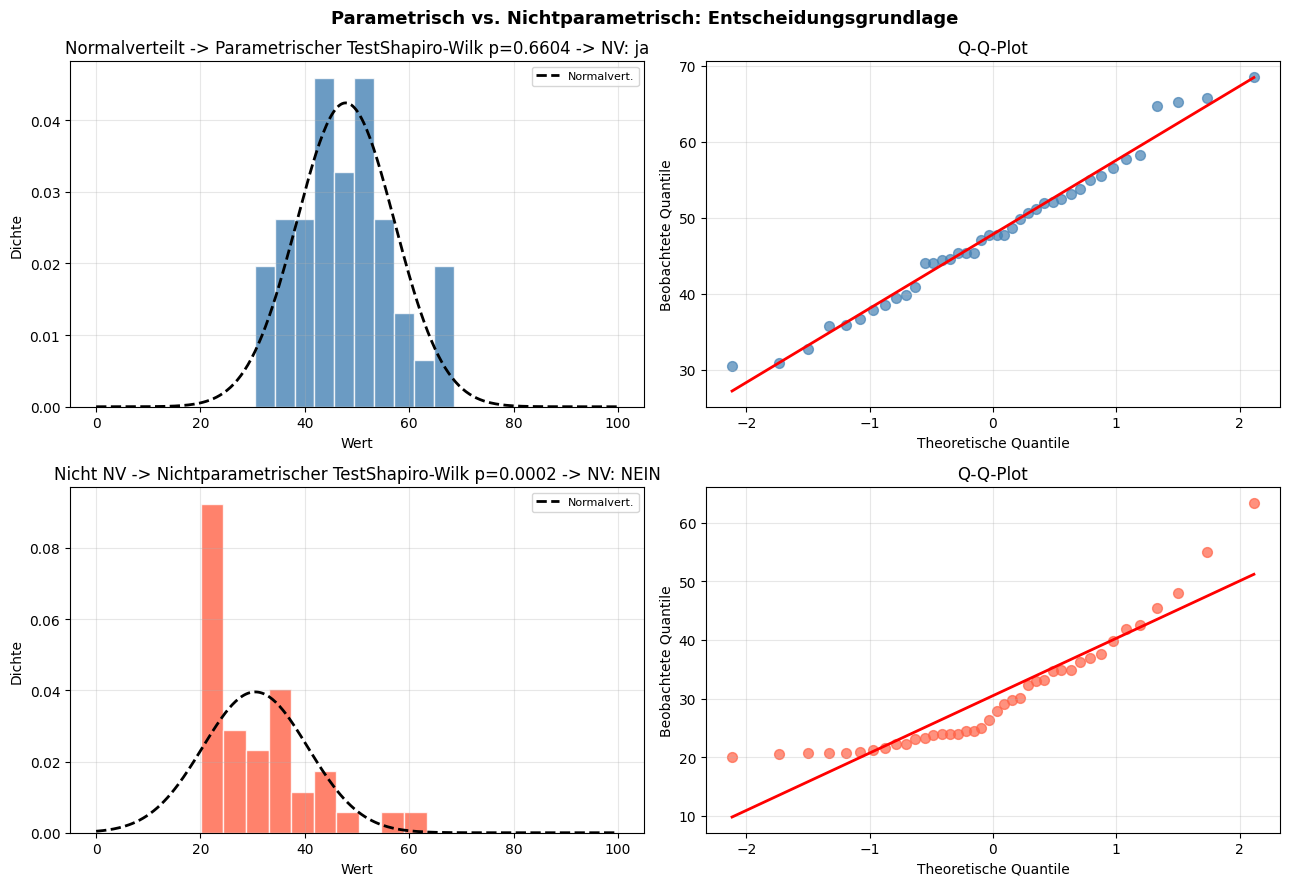

In [24]:
# Entscheidung visualisieren: normalverteilt vs. nicht normalverteilt
np.random.seed(42)
n = 40
daten_nv  = np.random.normal(50, 10, n)              # normalverteilt
daten_nnv = np.random.exponential(scale=10, size=n) + 20  # NICHT normalverteilt

w_nv,  p_nv  = shapiro(daten_nv)
w_nnv, p_nnv = shapiro(daten_nnv)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Parametrisch vs. Nichtparametrisch: Entscheidungsgrundlage",
             fontsize=13, fontweight="bold")

x_r = np.linspace(0, 100, 300)

for row, (daten, titel, p_sw, farbe) in enumerate([
    (daten_nv,  "Normalverteilt -> Parametrischer Test", p_nv,  "steelblue"),
    (daten_nnv, "Nicht NV -> Nichtparametrischer Test", p_nnv, "tomato"),
]):
    # Histogramm
    axes[row, 0].hist(daten, bins=10, color=farbe, edgecolor="white", alpha=0.8,
                      density=True)
    y_nv = norm_dist.pdf(x_r, daten.mean(), daten.std())
    axes[row, 0].plot(x_r, y_nv, color="black", linewidth=2, linestyle="--",
                      label="Normalvert.")
    sw_res = "NV: ja" if p_sw > 0.05 else "NV: NEIN"
    axes[row, 0].set_title(titel + "Shapiro-Wilk p=" + str(round(p_sw, 4))
                           + " -> " + sw_res)
    axes[row, 0].set_xlabel("Wert")
    axes[row, 0].set_ylabel("Dichte")
    axes[row, 0].legend(fontsize=8)
    axes[row, 0].grid(alpha=0.3)

    # Q-Q-Plot
    (osm, osr), (slope, intercept, _) = stats.probplot(daten, dist="norm")
    y_fit = slope * osm + intercept
    axes[row, 1].scatter(osm, osr, color=farbe, alpha=0.7, s=50)
    axes[row, 1].plot(osm, y_fit, color="red", linewidth=2)
    axes[row, 1].set_title("Q-Q-Plot")
    axes[row, 1].set_xlabel("Theoretische Quantile")
    axes[row, 1].set_ylabel("Beobachtete Quantile")
    axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Die Idee hinter nichtparametrischen Tests: Ränge

Nichtparametrische Tests ersetzen die Rohdaten durch ihre **Ränge**. Dadurch
werden Ausreißer und Nicht-Normalverteilung unschädlich gemacht.

**Beispiel:** Zwei Gruppen, Werte werden gemeinsam gerankt:
```
Rohdaten: Gruppe A: [3, 7, 5]   Gruppe B: [8, 12, 10]
Alle zusammen sortiert: 3, 5, 7, 8, 10, 12
Ränge:     Gruppe A: [1, 3, 2]   Gruppe B: [4, 6, 5]
```
Der Test prüft dann, ob die Ränge in beiden Gruppen ähnlich verteilt sind.

In [25]:
# Rang-Transformation demonstrieren
np.random.seed(42)
g_a = np.array([3.2, 7.1, 5.4, 2.8, 9.3])
g_b = np.array([8.5, 12.1, 10.7, 6.9, 15.2])

alle = np.concatenate([g_a, g_b])
gruppe = ["A"]*len(g_a) + ["B"]*len(g_b)

# Ränge berechnen
raenge = stats.rankdata(alle)
raenge_a = raenge[:len(g_a)]
raenge_b = raenge[len(g_a):]

print("Rang-Transformation")
print(f"{'Wert':>8} {'Gruppe':>8} {'Rang':>6}")
for w, g, r in sorted(zip(alle, gruppe, raenge)):
    print(f"{w:>8.1f} {g:>8} {r:>6.0f}")
print()
print(f"Mittlerer Rang Gruppe A: {raenge_a.mean():.2f}")
print(f"Mittlerer Rang Gruppe B: {raenge_b.mean():.2f}")
print()

# Vergleich: parametrisch vs. nichtparametrisch
t_stat, p_t = stats.ttest_ind(g_a, g_b)
u_stat, p_u = stats.mannwhitneyu(g_a, g_b, alternative="two-sided")
print(f"t-Test:          t={t_stat:.3f}, p={p_t:.4f}")
print(f"Mann-Whitney-U:  U={u_stat:.1f}, p={p_u:.4f}")

Rang-Transformation
    Wert   Gruppe   Rang
     2.8        A      1
     3.2        A      2
     5.4        A      3
     6.9        B      4
     7.1        A      5
     8.5        B      6
     9.3        A      7
    10.7        B      8
    12.1        B      9
    15.2        B     10

Mittlerer Rang Gruppe A: 3.60
Mittlerer Rang Gruppe B: 7.40

t-Test:          t=-2.716, p=0.0264
Mann-Whitney-U:  U=3.0, p=0.0556


## 3. Direkter Vergleich: Gleiche Daten, verschiedene Tests

Wir berechnen für **identische Daten** immer beide Varianten und vergleichen.

In [26]:
# Alle Paare auf denselben Datensätzen
np.random.seed(42)

print()
print("Vergleich parametrisch vs. nichtparametrisch (gleiche Daten)")
print()

# 1. Zwei unabhängige Gruppen (schief verteilt)
g1 = np.random.exponential(5, 25) + 5
g2 = np.random.exponential(5, 25) + 8

t_v, p_t = stats.ttest_ind(g1, g2)
u_v, p_u = stats.mannwhitneyu(g1, g2, alternative="two-sided")
print("1. Zwei unabh. Gruppen (schiefe Verteilung)")
print(f"   t-Test (parametrisch):     t={t_v:.3f}, p={p_t:.4f}")
print(f"   Mann-Whitney-U (nichtpar.): U={u_v:.1f}, p={p_u:.4f}")
print()

# 2. Zwei abhängige Gruppen (schief)
vorher = np.random.exponential(8, 20) + 10
nachher = vorher - np.random.exponential(2, 20)

t_v2, p_t2 = stats.ttest_rel(vorher, nachher)
w_v2, p_w2 = stats.wilcoxon(vorher, nachher)
print("2. Zwei abh. Gruppen (Vorher-Nachher)")
print(f"   Gepaarter t-Test:   t={t_v2:.3f}, p={p_t2:.4f}")
print(f"   Wilcoxon-Test:      W={w_v2:.1f}, p={p_w2:.4f}")
print()

# 3. Drei unabhängige Gruppen (schief)
g3_a = np.random.exponential(4, 20) + 5
g3_b = np.random.exponential(4, 20) + 8
g3_c = np.random.exponential(4, 20) + 12

F_v, p_F = stats.f_oneway(g3_a, g3_b, g3_c)
h_v, p_h = stats.kruskal(g3_a, g3_b, g3_c)
print("3. Drei unabh. Gruppen")
print(f"   ANOVA:           F={F_v:.3f}, p={p_F:.4f}")
print(f"   Kruskal-Wallis:  H={h_v:.3f}, p={p_h:.4f}")
print()

# 4. Korrelation (ordinale Daten)
x_ord = np.random.choice(range(1, 6), 30)
y_ord = x_ord + np.random.choice(range(-2, 3), 30)

r_p, p_p = stats.pearsonr(x_ord, y_ord)
r_s, p_s = stats.spearmanr(x_ord, y_ord)
print("4. Korrelation (ordinale Skala)")
print(f"   Pearson (parametrisch):   r={r_p:.3f}, p={p_p:.4f}")
print(f"   Spearman (nichtpar.):     r={r_s:.3f}, p={p_s:.4f}")


Vergleich parametrisch vs. nichtparametrisch (gleiche Daten)

1. Zwei unabh. Gruppen (schiefe Verteilung)
   t-Test (parametrisch):     t=-2.476, p=0.0169
   Mann-Whitney-U (nichtpar.): U=143.0, p=0.0010

2. Zwei abh. Gruppen (Vorher-Nachher)
   Gepaarter t-Test:   t=5.696, p=0.0000
   Wilcoxon-Test:      W=0.0, p=0.0000

3. Drei unabh. Gruppen
   ANOVA:           F=24.625, p=0.0000
   Kruskal-Wallis:  H=30.518, p=0.0000

4. Korrelation (ordinale Skala)
   Pearson (parametrisch):   r=0.611, p=0.0003
   Spearman (nichtpar.):     r=0.618, p=0.0003


## 4. Teststärke: Parametrisch ist sensitiver (wenn NV gilt)

Wenn die Normalverteilungsvoraussetzung **erfüllt** ist, hat der parametrische
Test eine **höhere Teststärke** – er findet echte Effekte häufiger.

Bei Verletzung der Normalverteilung dreht sich das um: dann ist der
nichtparametrische Test zuverlässiger.

Testärke-Simulation (n=20, delta=3.0, k=1000 Simulationen)

Wenn Normalverteilung GEGEBEN:
  t-Test (parametrisch):      Power = 46.8%
  Mann-Whitney-U (nichtpar.): Power = 44.4%

Wenn Normalverteilung VERLETZT (Exponentialvert.):
  t-Test (parametrisch):      Power = 50.1%
  Mann-Whitney-U (nichtpar.): Power = 73.1%

-> Bei NV: parametrisch sensitiver
-> Bei Verletzung: nichtparametrisch robuster oder gleichwertig


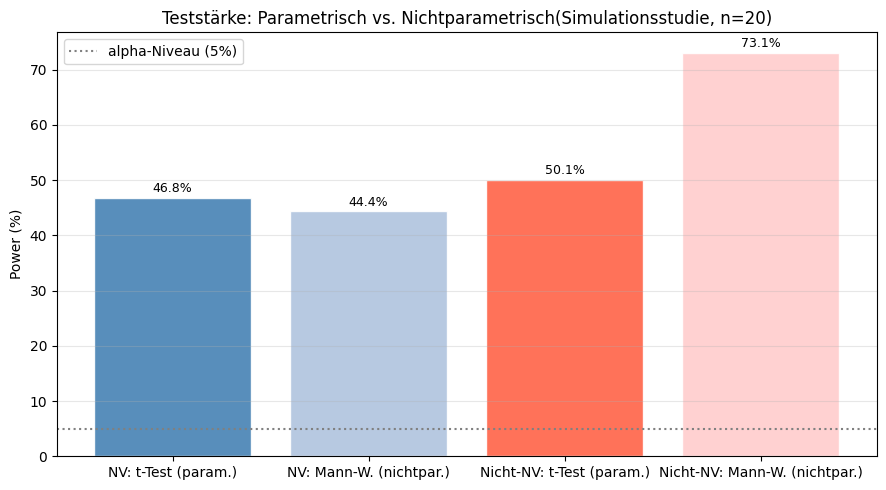

In [27]:
# Testärke-Simulation: NV erfüllt vs. verletzt
np.random.seed(42)
n_sim = 1000
n_stich = 20
alpha = 0.05
delta = 3.0  # wahrer Effekt

sig_t_nv, sig_u_nv   = 0, 0  # NV gegeben
sig_t_nnv, sig_u_nnv = 0, 0  # NV verletzt

for _ in range(n_sim):
    # NV: normalverteilt
    a_nv = np.random.normal(0,     5, n_stich)
    b_nv = np.random.normal(delta, 5, n_stich)
    _, p_t = stats.ttest_ind(a_nv, b_nv)
    _, p_u = stats.mannwhitneyu(a_nv, b_nv, alternative="two-sided")
    if p_t < alpha: sig_t_nv  += 1
    if p_u < alpha: sig_u_nv  += 1

    # Nicht NV: Exponentialverteilung
    a_nnv = np.random.exponential(5, n_stich)
    b_nnv = np.random.exponential(5, n_stich) + delta
    _, p_t2 = stats.ttest_ind(a_nnv, b_nnv)
    _, p_u2 = stats.mannwhitneyu(a_nnv, b_nnv, alternative="two-sided")
    if p_t2 < alpha: sig_t_nnv += 1
    if p_u2 < alpha: sig_u_nnv += 1

print("Testärke-Simulation (n=" + str(n_stich) + ", delta=" + str(delta) + ", k=" + str(n_sim) + " Simulationen)")
print()
print("Wenn Normalverteilung GEGEBEN:")
print(f"  t-Test (parametrisch):      Power = {sig_t_nv/n_sim*100:.1f}%")
print(f"  Mann-Whitney-U (nichtpar.): Power = {sig_u_nv/n_sim*100:.1f}%")
print()
print("Wenn Normalverteilung VERLETZT (Exponentialvert.):")
print(f"  t-Test (parametrisch):      Power = {sig_t_nnv/n_sim*100:.1f}%")
print(f"  Mann-Whitney-U (nichtpar.): Power = {sig_u_nnv/n_sim*100:.1f}%")
print()
print("-> Bei NV: parametrisch sensitiver")
print("-> Bei Verletzung: nichtparametrisch robuster oder gleichwertig")

# Visualisierung
fig, ax = plt.subplots(figsize=(9, 5))
kategorien = ["NV: t-Test (param.)", "NV: Mann-W. (nichtpar.)",
              "Nicht-NV: t-Test (param.)", "Nicht-NV: Mann-W. (nichtpar.)"]
werte = [sig_t_nv/n_sim*100, sig_u_nv/n_sim*100,
         sig_t_nnv/n_sim*100, sig_u_nnv/n_sim*100]
farben_p = ["steelblue", "#B0C4DE", "tomato", "#FFCCCC"]
bars = ax.bar(kategorien, werte, color=farben_p, edgecolor="white", alpha=0.9)
ax.axhline(alpha*100, color="gray", linestyle=":", linewidth=1.5,
           label="alpha-Niveau (5%)")
ax.set_title("Teststärke: Parametrisch vs. Nichtparametrisch(Simulationsstudie, n=" + str(n_stich) + ")")
ax.set_ylabel("Power (%)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, werte):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            str(round(val, 1)) + "%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Zusammenfassung

```
Parametrische vs. Nichtparametrische Tests
│
├── ENTSCHEIDUNGSKRITERIEN
│   1. Skalenniveau: metrisch? -> weiter
│      ordinal/nominal -> nichtparametrisch / Chi-Quadrat
│   2. Normalverteilung prüfen (Shapiro-Wilk, Q-Q-Plot)
│      NV gegeben (p > 0.05) -> parametrisch
│      NV verletzt           -> nichtparametrisch
│   3. n < 30? -> NV unsicher -> nichtparametrisch bevorzugen
│
├── TESTPAARE (numiqo-Tabelle)
│   1 Stichprobe:             Einstichproben-t   | Wilcoxon (1 Stichpr.)
│   2 abh. Stichproben:       Gepaarter t-Test   | Wilcoxon-Test
│   2 unabh. Stichproben:     Ungepaarter t-Test | Mann-Whitney-U
│   3+ unabh. Stichproben:    ANOVA              | Kruskal-Wallis
│   3+ abh. Stichproben:      ANOVA mit MWH      | Friedman-Test
│   Korrelation:              Pearson            | Spearman
│
├── PARAMETRISCH
│   + Höhere Teststärke (wenn Voraussetzungen erfüllt)
│   + Genauere Schätzungen
│   - Setzt NV voraus
│   - Metrisches Skalenniveau nötig
│
├── NICHTPARAMETRISCH
│   + Robust (keine Verteilungsannahme)
│   + Funktioniert auch bei ordinalem Skalenniveau
│   + Unempfindlich gegen Ausreisser
│   - Geringere Teststärke als parametrisch (bei NV)
│   - Basiert auf Rängen (nicht auf Rohdaten)
│
└── REGEL
    Wenn Voraussetzungen parametrisch erüllt sind:
    -> IMMER parametrischen Test bevorzugen!
```

---
Quelle: [numiqo.de/tutorial/parametrische-und-nichtparametrische-tests](https://numiqo.de/tutorial/parametrische-und-nichtparametrische-tests)